<h1><b>Análise Exploratória de Dados</b><br>
<i>Previsão de Demanda</i></h1>

<b>Dicionário de Dados:</b><br><i>
<b>date:</b> Data da venda.<br>
<b>store:</b> Identificador único da loja.<br>
<b>item:</b> Identificador único do produto.<br>
<b>sales:</b> Quantidade total vendida no dia.<br>

In [1]:
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_PATH = '../../data/raw/horizon_retail_supply.csv'
df = pd.read_csv(DATA_PATH)

df.head(2)

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11


In [21]:
print(df['store'].unique())
print(df['item'].unique())

[ 1  2  3  4  5  6  7  8  9 10]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]


In [23]:
Query = f"""
SELECT CASE
            WHEN date BETWEEN '2013-01-01' AND '2014-12-31' THEN '1. (2013-2014)'
            WHEN date BETWEEN '2015-01-01' AND '2016-12-31' THEN '2. (2015-2016)'
        END AS periodo,
EXTRACT(MONTH FROM CAST(date AS DATE)) AS mes, store, sum(sales) AS sales, item
FROM '{DATA_PATH }'
WHERE date BETWEEN '2013-01-01' AND '2016-12-31'
GROUP BY periodo, mes, store, item
ORDER BY periodo, mes, store, item
"""

resultado = duckdb.query(Query).to_df()

display(resultado)

,periodo,mes,store,sales,item
0,1. (2013-2014),1,1,763.0,1
1,1. (2013-2014),1,1,2027.0,2
2,1. (2013-2014),1,1,1201.0,3
3,1. (2013-2014),1,1,712.0,4
4,1. (2013-2014),1,1,606.0,5
...,...,...,...,...,...
11995,2. (2015-2016),12,10,3230.0,46
11996,2. (2015-2016),12,10,1206.0,47
11997,2. (2015-2016),12,10,2825.0,48
11998,2. (2015-2016),12,10,1640.0,49


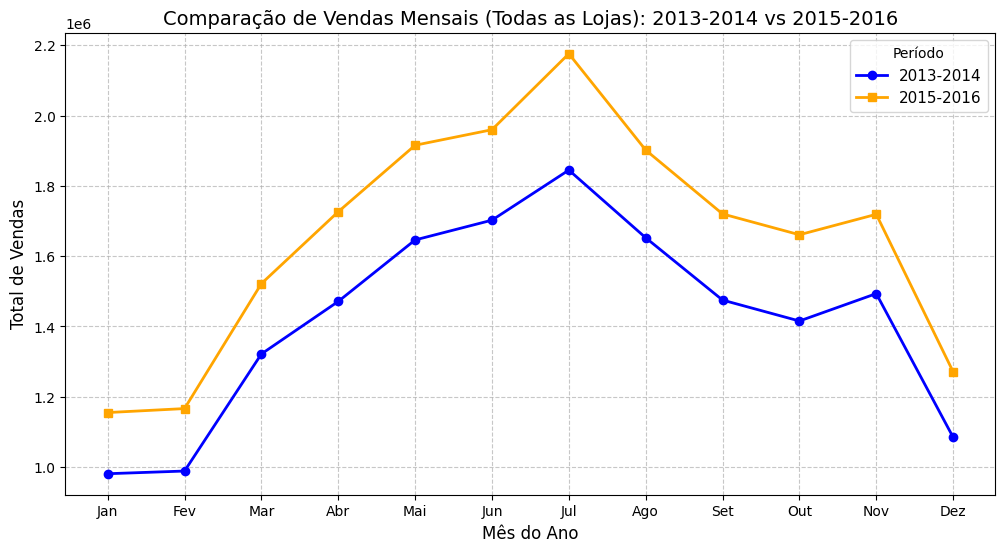

In [27]:
df_plot = resultado.groupby(['periodo', 'mes'])['sales'].sum().reset_index()


plt.figure(figsize=(12, 6))


periodo1 = df_plot[df_plot['periodo'] == '1. (2013-2014)']

plt.plot(periodo1['mes'], periodo1['sales'], marker='o', linestyle='-', linewidth=2, label='2013-2014', color='blue')


periodo2 = df_plot[df_plot['periodo'] == '2. (2015-2016)']

plt.plot(periodo2['mes'], periodo2['sales'], marker='s', linestyle='-', linewidth=2, label='2015-2016', color='orange')



plt.title('Comparação de Vendas Mensais (Todas as Lojas): 2013-2014 vs 2015-2016', fontsize=14)

plt.xlabel('Mês do Ano', fontsize=12)

plt.ylabel('Total de Vendas', fontsize=12)



plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])


plt.legend(title='Período', fontsize=11)

plt.grid(True, linestyle='--', alpha=0.7)


plt.show()

In [28]:
df_item_periodo = resultado.groupby(['item', 'periodo'])['sales'].sum().reset_index()
df_item_periodo['total_do_periodo'] = df_item_periodo.groupby('periodo')['sales'].transform('sum')
df_item_periodo['percentual'] = (df_item_periodo['sales'] / df_item_periodo['total_do_periodo']) * 100
df_plot_norm = df_item_periodo[df_item_periodo['item'].isin(top_10_itens)]


df_plot_barras = df_top10.groupby(['item', 'periodo'])['sales'].sum().reset_index()

sns.barplot(
    data=df_plot_norm,
    x='item',
    y='percentual',
    hue='periodo',
    palette=['#1f77b4', '#ff7f0e'] # Azul e Laranja padrão
)

plt.title('Porcentagem do item em relação ao total: Comparação 2013-2014 vs 2015-2016', fontsize=16, fontweight='bold')
plt.xlabel('Código', fontsize=12)
plt.ylabel('Total de Vendas', fontsize=12)

plt.legend(title='Período', fontsize=12)
plt.show()

NameError: name 'top_10_itens' is not defined

In [29]:
df_item_periodo = resultado.groupby(['item', 'periodo'])['sales'].sum().reset_index()
df_item_periodo['total_do_periodo'] = df_item_periodo.groupby('periodo')['sales'].transform('sum')
df_item_periodo['percentual'] = (df_item_periodo['sales'] / df_item_periodo['total_do_periodo']) * 100
df_plot_norm = df_item_periodo[df_item_periodo['item'].isin(top_10_itens)]


df_plot_barras = df_top10.groupby(['item', 'periodo'])['sales'].sum().reset_index()

sns.barplot(
    data=df_plot_norm,
    x='item',
    y='percentual',
    hue='periodo',
    palette=['#1f77b4', '#ff7f0e'] # Azul e Laranja padrão
)

plt.title('Porcentagem do item em relação ao total: Comparação 2013-2014 vs 2015-2016', fontsize=16, fontweight='bold')
plt.xlabel('Código', fontsize=12)
plt.ylabel('Total de Vendas', fontsize=12)

plt.legend(title='Período', fontsize=12)
plt.show()

NameError: name 'top_10_itens' is not defined